<a href="https://colab.research.google.com/github/bahmedx/730/blob/main/Sentiment_Analysis_Customer_Feedback.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Sentiment Analysis for Customer Feedback in the Airline Industry**

### **Research Project - Case Study Part 1**

**Research purpose**

This notebook develops and evaluates natural-language-processing (NLP) models tonatural language processing (NLP) models toThis notebook develops and evaluates natural-language-processing (NLP) models that classify airline customer feedback as **negative, neutral, or positive**. It uses the **Twitter US Airline Sentiment** dataset (14,640 labeled tweets when the standard Kaggle file is supplied), performs reproducible preprocessing and TF-IDF feature extraction, compares **Multinomial Naive Bayes** and **Linear Support Vector Machine (LinearSVC)** on the same stratified held-out test set, and adds an optional transformer benchmark when the required package/model is available.

**Research questions**

How effectively can TF-IDF-based machine learning models classify airline customer feedback as negative, neutral, or positive, and which evaluated model provides the strongest performance across the three sentiment classes?

**Required workflow covered**
- Data collection, validation, and exploratory analysis
- Cleaning, tokenization, stop-word removal, and lemmatization
- TF-IDF unigram/bigram feature extraction
- Naive Bayes and Linear SVM model development
- Accuracy, precision, recall, F1-score, classification reports, and confusion matrices
- Model interpretation and business implications
- Reproducibility guidance and Case Study #2 presentation connection

**Methodological guardrail:** The primary comparison is between Naive Bayes and Linear SVM because both solve the same three-class task on the identical held-out test set. The optional DistilBERT/SST-2 analysis is explicitly exploratory because SST-2 is binary (positive/negative), not a native three-class airline sentiment model.

## 1. Environment setup
Run this notebook top-to-bottom in Google Colab. The core analysis uses pandas, NumPy, NLTK, scikit-learn, seaborn, and matplotlib.

In [15]:
# Core imports and reproducibility
import io, os, re, sys, zipfile, warnings, random
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

for package in ["stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"]:
    nltk.download(package, quiet=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

print("Python:", sys.version.split()[0])
print("pandas:", pd.__version__)
print("NumPy:", np.__version__)
print("Environment ready. Random seed =", SEED)

Python: 3.13.16
pandas: 2.2.3
NumPy: 2.1.3
Environment ready. Random seed = 42


## 2. Data collection and ingestion

Download the **Twitter US Airline Sentiment** dataset from the assignment's Kaggle page and upload either `archive.zip` or `Tweets.csv` when prompted. This avoids dependence on unofficial data mirrors and makes the source explicit.

The loader also checks `/content/archive.zip`, `/content/Tweets.csv`, and equivalent local paths before opening an upload dialog.

In [16]:
# Robust local/Colab loader. No unofficial mirror is required.
def read_airline_file(path_or_bytes, name=None):
    """Read Tweets.csv directly or extract the first matching CSV from a ZIP archive."""
    filename = name or (path_or_bytes if isinstance(path_or_bytes, str) else "uploaded_file")
    lower = str(filename).lower()
    if lower.endswith(".zip"):
        zf = zipfile.ZipFile(path_or_bytes if not isinstance(path_or_bytes, str) else path_or_bytes)
        candidates = [n for n in zf.namelist() if os.path.basename(n).lower() == "tweets.csv"]
        if not candidates:
            candidates = [n for n in zf.namelist() if n.lower().endswith(".csv")]
        if not candidates:
            raise FileNotFoundError("No CSV file was found inside the ZIP archive.")
        return pd.read_csv(zf.open(candidates[0]))
    return pd.read_csv(path_or_bytes)

def load_dataset():
    local_candidates = [
        "/content/Tweets.csv", "/content/archive.zip",
        "Tweets.csv", "archive.zip"
    ]
    for path in local_candidates:
        if os.path.exists(path):
            print(f"Loading local file: {path}")
            return read_airline_file(path)

    try:
        from google.colab import files
        print("Upload the Kaggle archive.zip or Tweets.csv file.")
        uploaded = files.upload()
        if not uploaded:
            raise RuntimeError("No file was uploaded.")
        filename, data = next(iter(uploaded.items()))
        return read_airline_file(io.BytesIO(data), filename)
    except ImportError as exc:
        raise FileNotFoundError(
            "Tweets.csv/archive.zip not found. Place the Kaggle file in the working directory."
        ) from exc

df_raw = load_dataset()
print(f"Raw shape: {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
display(df_raw.head(3))

Loading local file: /content/archive.zip
Raw shape: 14,640 rows x 15 columns


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials t...,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I n...,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)


## 3. Data validation and analytic sample
The following checks prevent silent schema or label errors before modeling.

In [17]:
required = {"text", "airline_sentiment", "airline", "negativereason"}
missing = required - set(df_raw.columns)

if missing:
    raise ValueError(f"Missing required columns: {sorted(missing)}")

df = df_raw[
    ["text", "airline_sentiment", "airline", "negativereason"]
].copy()

df = df.dropna(subset=["text", "airline_sentiment"])

df["airline_sentiment"] = (
    df["airline_sentiment"]
    .astype(str)
    .str.lower()
    .str.strip()
)

valid_labels = {"negative", "neutral", "positive"}
observed = set(df["airline_sentiment"].unique())

if not observed.issubset(valid_labels):
    raise ValueError(
        f"Unexpected sentiment labels: {sorted(observed - valid_labels)}"
    )

# Check and remove exact duplicate tweet text
duplicate_count = df["text"].duplicated().sum()

print(f"Initial analytic sample: {len(df):,} rows")
print(f"Missing text: {df['text'].isna().sum():,}")
print(f"Exact duplicate tweet texts: {duplicate_count:,}")

df = df.drop_duplicates(subset=["text"], keep="first").copy()

print(f"Duplicates removed: {duplicate_count:,}")
print(f"Final analytic sample: {len(df):,} rows")

# Verify duplicate removal
remaining_duplicates = df["text"].duplicated().sum()
assert remaining_duplicates == 0, "Duplicate text remains after removal."

# Recalculate sentiment distribution after duplicate removal
distribution = (
    df["airline_sentiment"]
    .value_counts()
    .rename_axis("sentiment")
    .reset_index(name="count")
)

distribution["percent"] = (
    100 * distribution["count"] / len(df)
)

display(
    distribution.style.format(
        {"percent": "{:.1f}%"}
    )
)

Initial analytic sample: 14,640 rows
Missing text: 0
Exact duplicate tweet texts: 213
Duplicates removed: 213
Final analytic sample: 14,427 rows


,sentiment,count,percent
0,negative,9080,62.9%
1,neutral,3057,21.2%
2,positive,2290,15.9%


## 4. Exploratory data analysis
Class balance is examined before modeling because overall accuracy can be misleading when one sentiment is substantially more common.

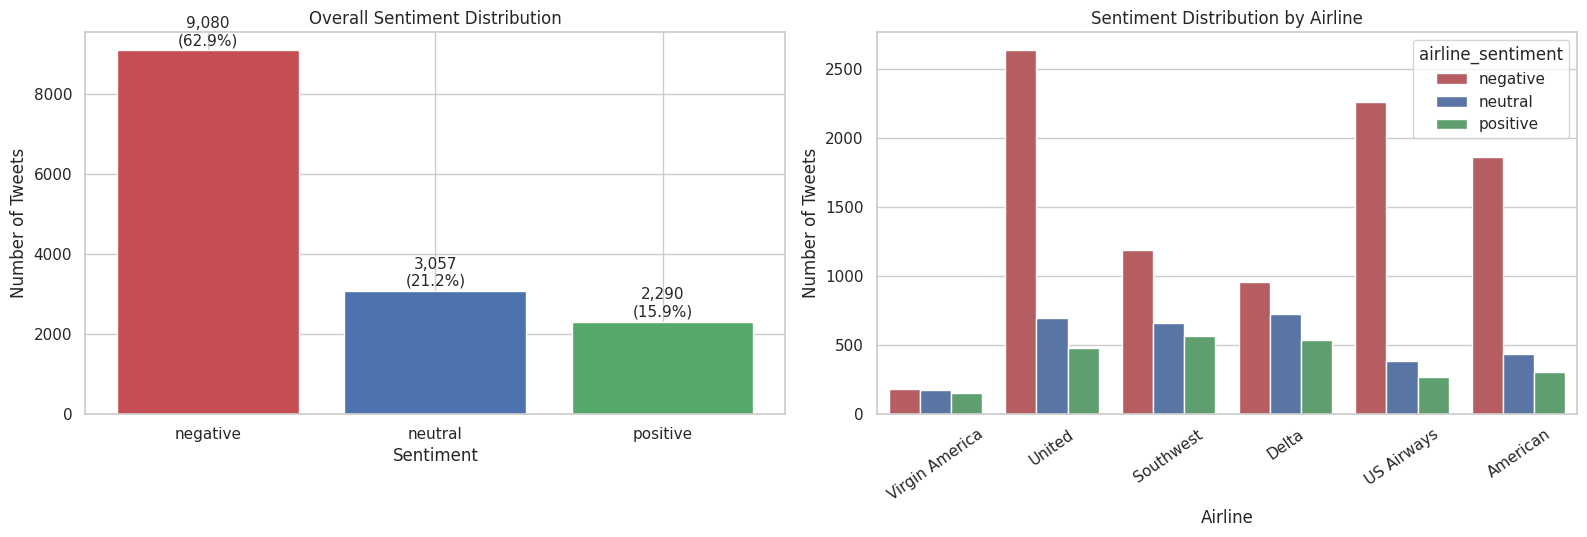

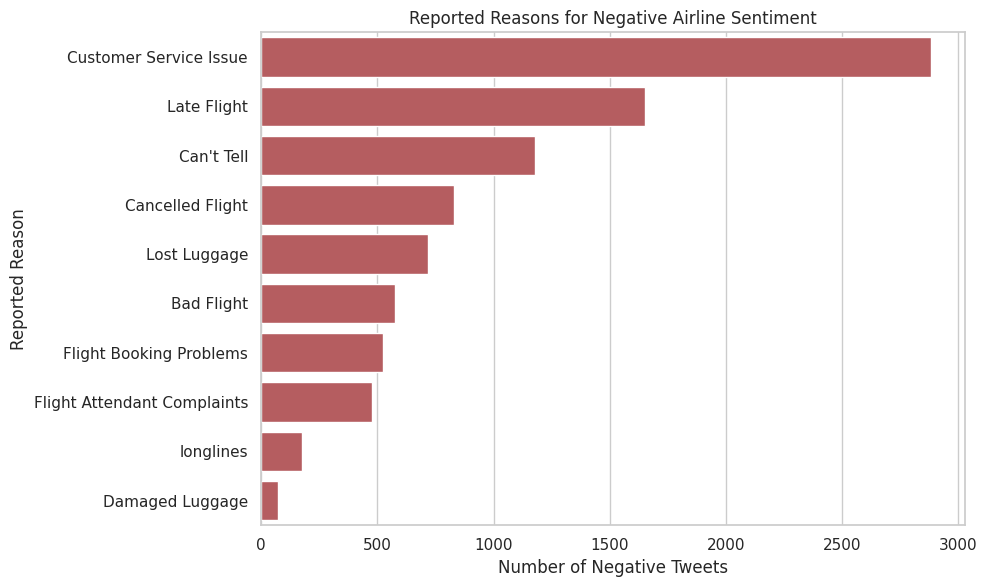

Top three reported negative reasons:


,count
negativereason,
Customer Service Issue,2883
Late Flight,1650
Can't Tell,1176


Together they represent 62.9% of negative tweets with a recorded reason.


In [18]:
label_order = ["negative", "neutral", "positive"]
palette = {"negative":"#C44E52", "neutral":"#4C72B0", "positive":"#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))
counts = df["airline_sentiment"].value_counts().reindex(label_order)
axes[0].bar(counts.index, counts.values, color=[palette[x] for x in counts.index])
axes[0].set(title="Overall Sentiment Distribution", xlabel="Sentiment", ylabel="Number of Tweets")
for i, v in enumerate(counts.values):
    axes[0].text(i, v + max(counts)*0.015, f"{v:,}\n({v/len(df):.1%})", ha="center")

sns.countplot(data=df, x="airline", hue="airline_sentiment", hue_order=label_order,
              palette=palette, ax=axes[1])
axes[1].set(title="Sentiment Distribution by Airline", xlabel="Airline", ylabel="Number of Tweets")
axes[1].tick_params(axis="x", rotation=35)
plt.tight_layout(); plt.show()

neg_reasons = (df.loc[df["airline_sentiment"].eq("negative"), "negativereason"]
               .dropna().value_counts())
plt.figure(figsize=(10, 6))
sns.barplot(x=neg_reasons.values, y=neg_reasons.index, color="#C44E52")
plt.title("Reported Reasons for Negative Airline Sentiment")
plt.xlabel("Number of Negative Tweets"); plt.ylabel("Reported Reason")
plt.tight_layout(); plt.show()

# Evidence-backed top-three share, rather than an unsupported percentage.
top3 = neg_reasons.head(3)
known_reason_total = neg_reasons.sum()
print("Top three reported negative reasons:")
display(top3.rename("count").to_frame())
if known_reason_total:
    print(f"Together they represent {top3.sum()/known_reason_total:.1%} of negative tweets with a recorded reason.")

## 5. Text preprocessing

The classical models use a transparent NLP pipeline:

1. Remove URLs and Twitter handles.
2. Remove punctuation/non-alphabetic characters and lowercase text.
3. Tokenize with NLTK.
4. Remove English stop words while **retaining common negation forms**, because negation can reverse sentiment.
5. Lemmatize tokens with WordNet.

A limitation is that aggressive normalization may discard emojis, punctuation intensity, and some social-media cues. The raw text is retained separately for optional transformer inference.

In [19]:
stop_words = set(stopwords.words("english"))
negations = {"no", "nor", "not", "never", "cannot", "couldn", "didn", "doesn", "hadn",
             "hasn", "haven", "isn", "mightn", "mustn", "needn", "shan", "shouldn",
             "wasn", "weren", "won", "wouldn"}
filtered_stopwords = stop_words - negations
lemmatizer = WordNetLemmatizer()

def preprocess_text(text):
    if not isinstance(text, str):
        return ""
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"@[A-Za-z0-9_]+", " ", text)
    text = re.sub(r"[^A-Za-z\s]", " ", text).lower()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(t) for t in tokens
              if t not in filtered_stopwords and len(t) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(preprocess_text)
empty_mask = df["clean_text"].str.strip().eq("")
print(f"Empty cleaned documents: {empty_mask.sum():,}")
# Remove empty documents before stratified splitting.
df_model = df.loc[~empty_mask].copy()

display(df_model[["text", "clean_text", "airline_sentiment"]].head(5))

Empty cleaned documents: 37


,text,clean_text,airline_sentiment
0,@VirginAmerica What @dhepburn said.,said,neutral
1,@VirginAmerica plus you've added commercials t...,plus added commercial experience tacky,positive
2,@VirginAmerica I didn't today... Must mean I n...,didn today must mean need take another trip,neutral
3,@VirginAmerica it's really aggressive to blast...,really aggressive blast obnoxious entertainmen...,negative
4,@VirginAmerica and it's a really big bad thing...,really big bad thing,negative


## 6. Stratified split and TF-IDF feature extraction
The vectorizer is **fit only on training text** to prevent information leakage from the held-out test set. Unigrams and bigrams capture individual words plus short phrases.

In [20]:
X = df_model["clean_text"]
y = df_model["airline_sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y
)

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

print(f"Training observations: {len(X_train):,}")
print(f"Test observations:     {len(X_test):,}")
print("Training TF-IDF matrix:", X_train_tfidf.shape)
print("Test TF-IDF matrix:    ", X_test_tfidf.shape)

Training observations: 11,512
Test observations:     2,878
Training TF-IDF matrix: (11512, 5000)
Test TF-IDF matrix:     (2878, 5000)


## 7. Model development
Two models are trained under the same split and representation: **Multinomial Naive Bayes** as a probabilistic text baseline and **Linear SVM** as a strong sparse high-dimensional classifier.

In [21]:
models = {
    "Multinomial Naive Bayes": MultinomialNB(alpha=1.0),
    "Linear SVM": LinearSVC(C=1.0, random_state=SEED)
}

predictions = {}
for name, model in models.items():
    model.fit(X_train_tfidf, y_train)
    predictions[name] = model.predict(X_test_tfidf)
    print(f"Trained: {name}")

Trained: Multinomial Naive Bayes
Trained: Linear SVM


## 8. Evaluation and model comparison
Because the classes are imbalanced, this notebook reports **accuracy plus macro and weighted precision, recall, and F1**. Macro averages weight each class equally; weighted averages reflect class frequency.

In [22]:
def metric_row(name, y_true, y_pred):
    p_ma, r_ma, f_ma, _ = precision_recall_fscore_support(
        y_true, y_pred, average="macro", zero_division=0)
    p_w, r_w, f_w, _ = precision_recall_fscore_support(
        y_true, y_pred, average="weighted", zero_division=0)
    return {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (Macro)": p_ma,
        "Recall (Macro)": r_ma,
        "F1 (Macro)": f_ma,
        "Precision (Weighted)": p_w,
        "Recall (Weighted)": r_w,
        "F1 (Weighted)": f_w
    }

results_df = pd.DataFrame([
    metric_row(name, y_test, pred) for name, pred in predictions.items()
]).sort_values(["F1 (Macro)", "Accuracy"], ascending=False).reset_index(drop=True)

display(results_df.style.format({c:"{:.3f}" for c in results_df.columns if c != "Model"}))

best_name = results_df.loc[0, "Model"]
best_pred = predictions[best_name]
print(f"Selected model by Macro F1: {best_name}")
print("\nDetailed classification report:")
print(classification_report(y_test, best_pred, labels=label_order, target_names=[x.title() for x in label_order], zero_division=0))

,Model,Accuracy,Precision (Macro),Recall (Macro),F1 (Macro),Precision (Weighted),Recall (Weighted),F1 (Weighted)
0,Linear SVM,0.777,0.722,0.687,0.702,0.769,0.777,0.771
1,Multinomial Naive Bayes,0.737,0.768,0.545,0.584,0.747,0.737,0.693


Selected model by Macro F1: Linear SVM

Detailed classification report:
              precision    recall  f1-score   support

    Negative       0.83      0.90      0.86      1814
     Neutral       0.61      0.53      0.57       607
    Positive       0.72      0.63      0.67       457

    accuracy                           0.78      2878
   macro avg       0.72      0.69      0.70      2878
weighted avg       0.77      0.78      0.77      2878



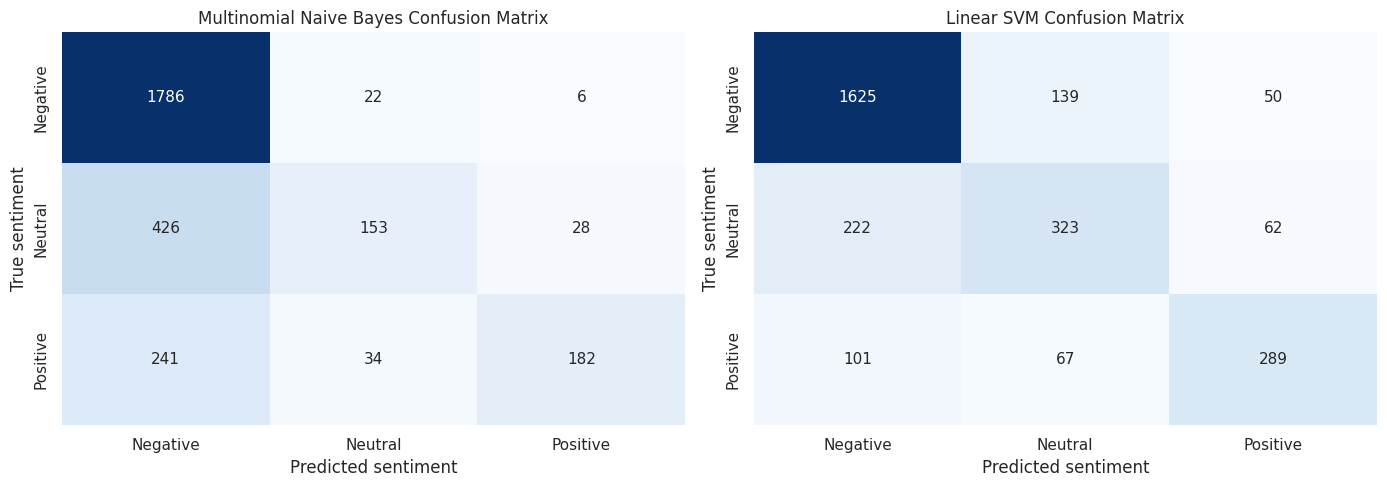

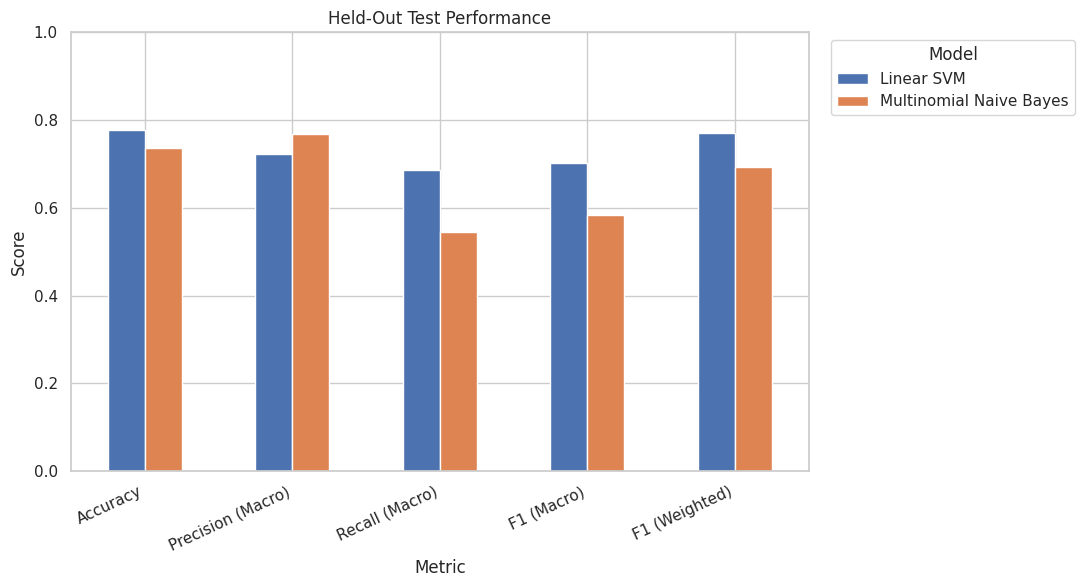

In [23]:
# Confusion matrices using the same label order for both models.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, (name, pred) in zip(axes, predictions.items()):
    cm = confusion_matrix(y_test, pred, labels=label_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False,
                xticklabels=[x.title() for x in label_order],
                yticklabels=[x.title() for x in label_order], ax=ax)
    ax.set_title(f"{name} Confusion Matrix")
    ax.set_xlabel("Predicted sentiment"); ax.set_ylabel("True sentiment")
plt.tight_layout(); plt.show()

# Visual comparison of core metrics
plot_cols = ["Accuracy", "Precision (Macro)", "Recall (Macro)", "F1 (Macro)", "F1 (Weighted)"]
plot_df = results_df.set_index("Model")[plot_cols].T
ax = plot_df.plot(kind="bar", figsize=(11, 6), ylim=(0, 1))
ax.set_title("Held-Out Test Performance")
ax.set_ylabel("Score"); ax.set_xlabel("Metric")
ax.legend(title="Model", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=25, ha="right"); plt.tight_layout(); plt.show()

## 9. Error analysis
Inspecting misclassifications provides context that aggregate metrics cannot show and helps identify difficult classes or ambiguous language.

In [24]:
error_df = df_model.loc[X_test.index, ["text", "clean_text", "airline_sentiment"]].copy()
error_df["predicted"] = best_pred
errors = error_df[error_df["airline_sentiment"] != error_df["predicted"]]
print(f"Misclassified test observations: {len(errors):,} of {len(error_df):,} ({len(errors)/len(error_df):.1%})")
display(errors[["text", "airline_sentiment", "predicted"]].head(12))

Misclassified test observations: 641 of 2,878 (22.3%)


,text,airline_sentiment,predicted
5465,@SouthwestAir my father was kind enough to off...,neutral,negative
11940,@AmericanAir I need a flight out tonight. Isn'...,negative,neutral
2474,@united I was just calling the Global Services...,neutral,negative
2727,@united Help! My girlfriend Amy Lloyd is going...,negative,neutral
438,@VirginAmerica I miss the #nerdbird in San Jose,neutral,negative
989,"@united Thank you, ^JH, appreciate the prompt ...",neutral,positive
7279,@JetBlue @zakkohane pretty sure he's saying Ri...,neutral,positive
14612,@AmericanAir a friend is having flight Cancell...,negative,neutral
5854,@SouthwestAir flight # 317,negative,neutral
11727,@USAirways Sending thanks to employee Freddie ...,positive,negative


## 10. Interpretability of the Linear SVM
For a multiclass LinearSVC, larger positive class-specific coefficients indicate TF-IDF features more strongly associated with that one-vs-rest class. Coefficients indicate model association, **not causal effects**.

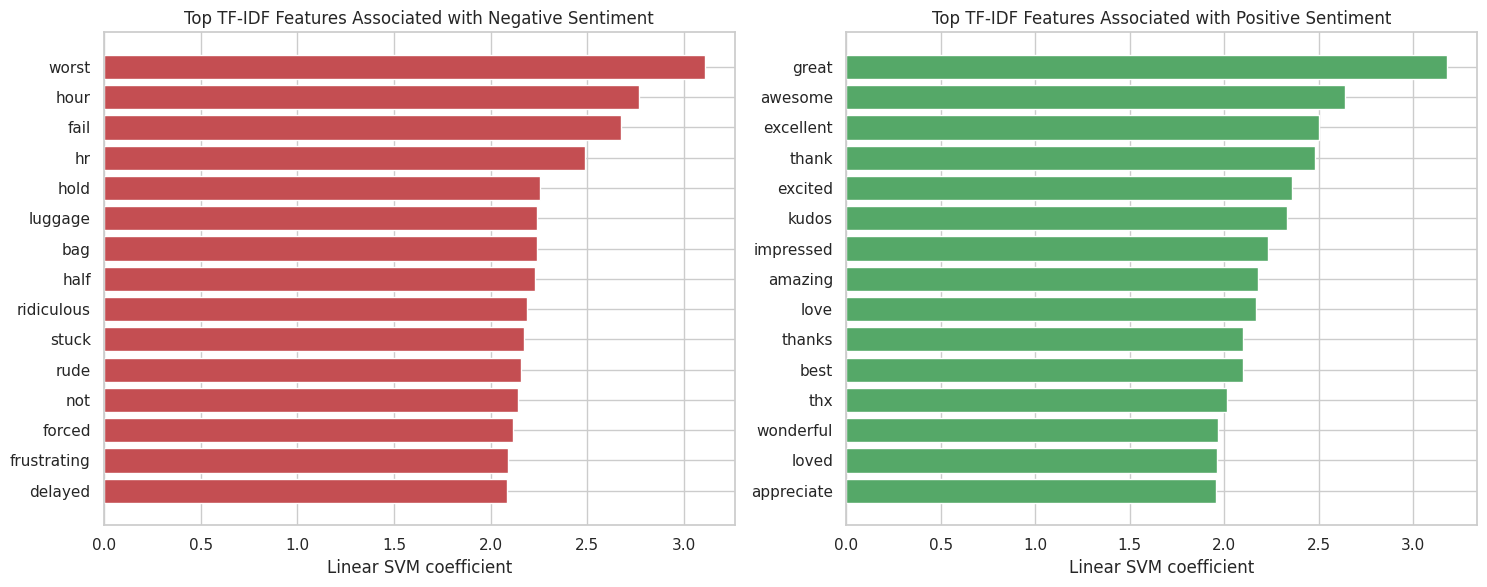

In [25]:
svm = models["Linear SVM"]
feature_names = np.asarray(tfidf.get_feature_names_out())
classes = list(svm.classes_)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for ax, target, color in zip(axes, ["negative", "positive"], ["#C44E52", "#55A868"]):
    class_idx = classes.index(target)
    coef = svm.coef_[class_idx].ravel()
    top_idx = np.argsort(coef)[-15:]
    order = np.argsort(coef[top_idx])
    ax.barh(feature_names[top_idx][order], coef[top_idx][order], color=color)
    ax.set_title(f"Top TF-IDF Features Associated with {target.title()} Sentiment")
    ax.set_xlabel("Linear SVM coefficient")
plt.tight_layout(); plt.show()

## 11. Optional exploratory transformer benchmark

This section is **not part of the primary three-class model comparison**. `distilbert-base-uncased-finetuned-sst-2-english` predicts only positive vs. negative sentiment, whereas this research task has negative, neutral, and positive classes. If `transformers` is installed and model weights are available, the code below evaluates the binary model only on the subset of test observations whose true labels are positive or negative.

This preserves methodological validity: neutral observations are not artificially assigned to a binary model, and the transformer's results are not ranked against the three-class Naive Bayes/SVM table.

In [26]:
RUN_TRANSFORMER_BENCHMARK = False  # Set True in an internet-enabled Colab runtime if desired.

if RUN_TRANSFORMER_BENCHMARK:
    try:
        import torch
        from transformers import pipeline

        device = 0 if torch.cuda.is_available() else -1
        clf = pipeline(
            "sentiment-analysis",
            model="distilbert-base-uncased-finetuned-sst-2-english",
            device=device
        )
        binary_idx = y_test[y_test.isin(["negative", "positive"])].index
        raw_binary = df_model.loc[binary_idx, "text"].tolist()
        true_binary = y_test.loc[binary_idx].tolist()
        out = clf(raw_binary, truncation=True, batch_size=32)
        pred_binary = [r["label"].lower() for r in out]
        print("Exploratory binary DistilBERT benchmark")
        print(classification_report(true_binary, pred_binary, labels=["negative", "positive"], zero_division=0))
    except Exception as exc:
        print("Transformer benchmark skipped:", exc)
else:
    print("Transformer benchmark intentionally skipped. Core submission does not depend on it.")

Transformer benchmark intentionally skipped. Core submission does not depend on it.


## 12. Empirical Results Summary
The next cell generates evidence-backed statements from the executed results rather than hard-coding performance claims.

In [27]:
best = results_df.iloc[0]
print("Empirical Results Summary")
print(f"- Best primary model: {best['Model']}")
print(f"- Held-out accuracy: {best['Accuracy']:.2%}")
print(f"- Macro F1: {best['F1 (Macro)']:.3f}")
print(f"- Weighted F1: {best['F1 (Weighted)']:.3f}")

if len(neg_reasons):
    print(f"- Most frequent recorded negative reason: {neg_reasons.index[0]} ({neg_reasons.iloc[0]:,} tweets)")

Empirical Results Summary
- Best primary model: Linear SVM
- Held-out accuracy: 77.73%
- Macro F1: 0.702
- Weighted F1: 0.771
- Most frequent recorded negative reason: Customer Service Issue (2,883 tweets)
